In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'apple fruit'	'chickoo fruit'  'mango fruit'
'banana fruit'	'grapes fruit'	 'orange fruit'
'cherry fruit'	'kiwi fruit'	 'strawberry fruit'


In [3]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = [
    "apple fruit",
    "banana fruit",
    "cherry fruit",
    "chickoo fruit",
    "grapes fruit",
    "kiwi fruit",
    "mango fruit",
    "orange fruit",
    "strawberry fruit"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

Number of Classes: 9


In [4]:
def read_decode(filename,resize_dims):
  img_bytes = tf.io.read_file(filename)
  img = tf.image.decode_jpeg(img_bytes,channels=IMG_CHANNELS)
  img = tf.image.convert_image_dtype(img,tf.float32)
  img = tf.image.resize(img,resize_dims)
  return img

In [5]:
def parse_csvline(csv_line):
   record_default = ["",""]
   filename,label_string = tf.io.decode_csv(csv_line,record_default)
   img = read_decode(filename,[IMG_HEIGHT, IMG_WIDTH])

   label =tf.argmax(tf.math.equal(CLASS_NAMES,label_string))
   return img, label

In [6]:
import os
import math
import random
import pathlib

random.seed(42)

# Dataset Path
data_dir = pathlib.Path(
    "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"
)

CLASS_NAMES_PY = [
    'apple fruit',
    'banana fruit',
    'cherry fruit',
    'chickoo fruit',
    'grapes fruit',
    'kiwi fruit',
    'mango fruit',
    'orange fruit',
    'strawberry fruit'
]

TRAIN_CSV = '/tmp/train_set.csv'
EVAL_CSV  = '/tmp/eval_set.csv'

train_rows = []
eval_rows = []

for cls in CLASS_NAMES_PY:
    cls_dir = data_dir / cls

    images = sorted(str(p) for p in cls_dir.glob('*.jpg'))

    random.shuffle(images)

    split = math.ceil(len(images) * 0.8)

    train_rows += [(p, cls) for p in images[:split]]
    eval_rows += [(p, cls) for p in images[split:]]

random.shuffle(train_rows)
random.shuffle(eval_rows)

with open(TRAIN_CSV, 'w') as f:
    for path, label in train_rows:
        f.write(f"{path},{label}\n")

with open(EVAL_CSV, 'w') as f:
    for path, label in eval_rows:
        f.write(f"{path},{label}\n")

print("Train samples:", len(train_rows))
print("Eval samples :", len(eval_rows))



Train samples: 255
Eval samples : 60


In [7]:
train_dataset = (
    tf.data.TextLineDataset(TRAIN_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset(EVAL_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


In [8]:
for image_batch, label_batch in train_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Labels: [3 4 2 4 0 4 8 5 1 0 5 2 1 6 6 0]


In [23]:
print("Classes:", CLASS_NAMES)
print("Number of Classes:", len(CLASS_NAMES))




print("Height:", IMG_HEIGHT)
print("Width:", IMG_WIDTH)
print("Channels:", IMG_CHANNELS)

Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Number of Classes: 9
Height: 224
Width: 224
Channels: 3


In [26]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 360 files belonging to 9 classes.
Using 288 files for training.
Found 360 files belonging to 9 classes.
Using 72 files for validation.


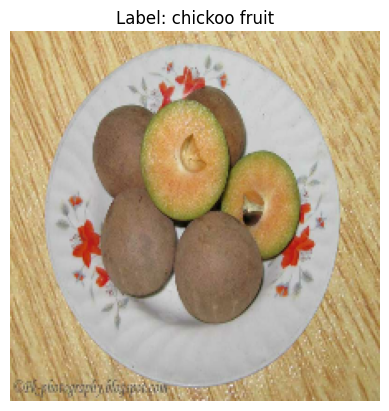

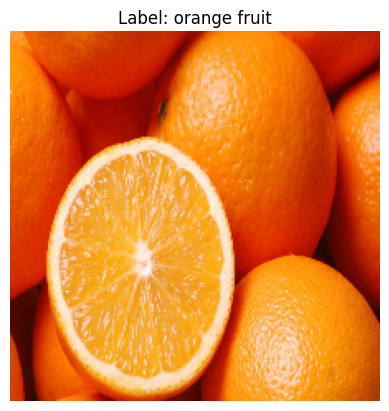

In [9]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

In [27]:
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

model = keras.Sequential([

    data_augmentation,

    layers.Conv2D(32,(3,3),activation="relu",
                  input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(9, activation="softmax")
])

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.1458 - loss: 2.3265 - val_accuracy: 0.1528 - val_loss: 3.2283
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2743 - loss: 2.0681 - val_accuracy: 0.2361 - val_loss: 2.6578
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 834ms/step - accuracy: 0.3611 - loss: 1.8575 - val_accuracy: 0.2361 - val_loss: 2.4781
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3576 - loss: 1.8810 - val_accuracy: 0.2222 - val_loss: 2.3721
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 971ms/step - accuracy: 0.4271 - loss: 1.7416 - val_accuracy: 0.2222 - val_loss: 2.2844
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 892ms/step - accuracy: 0.4375 - loss: 1.6944 - val_accuracy: 0.2222 - val_loss: 2.2100
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4444 - loss: 1.6030 - val_accuracy: 0.2222 - val_loss: 2.1508
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 988ms/step - accuracy: 0.4757 - loss: 1.5682 - val_accuracy: 0.2083 - val_loss: 2.1149
E

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 665ms/step - accuracy: 0.2000 - loss: 3.5034 - val_accuracy: 0.1000 - val_loss: 2.3030
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 593ms/step - accuracy: 0.3765 - loss: 2.5402 - val_accuracy: 0.1000 - val_loss: 2.8713
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 678ms/step - accuracy: 0.4392 - loss: 2.0577 - val_accuracy: 0.1000 - val_loss: 3.5841
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 696ms/step - accuracy: 0.4941 - loss: 1.7259 - val_accuracy: 0.1000 - val_loss: 4.3136
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 663ms/step - accuracy: 0.5059 - loss: 1.6991 - val_accuracy: 0.1000 - val_loss: 4.7958
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 601ms/step - accuracy: 0.5647 - loss: 1.4460 - val_accuracy: 0.1000 - val_loss: 5.4395
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.5216 - loss: 1.4666 - val_accuracy: 0.1000 - val_loss: 5.7748
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 709ms/step - accuracy: 0.5647 - loss: 1.3134 - val_accurac

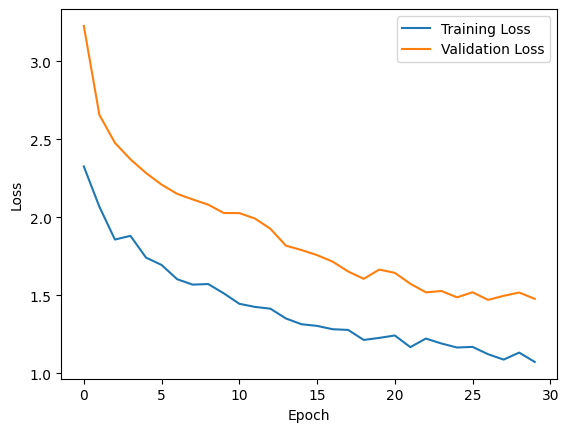

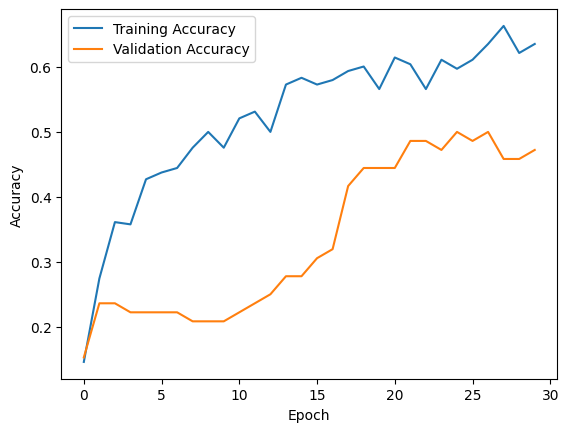

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


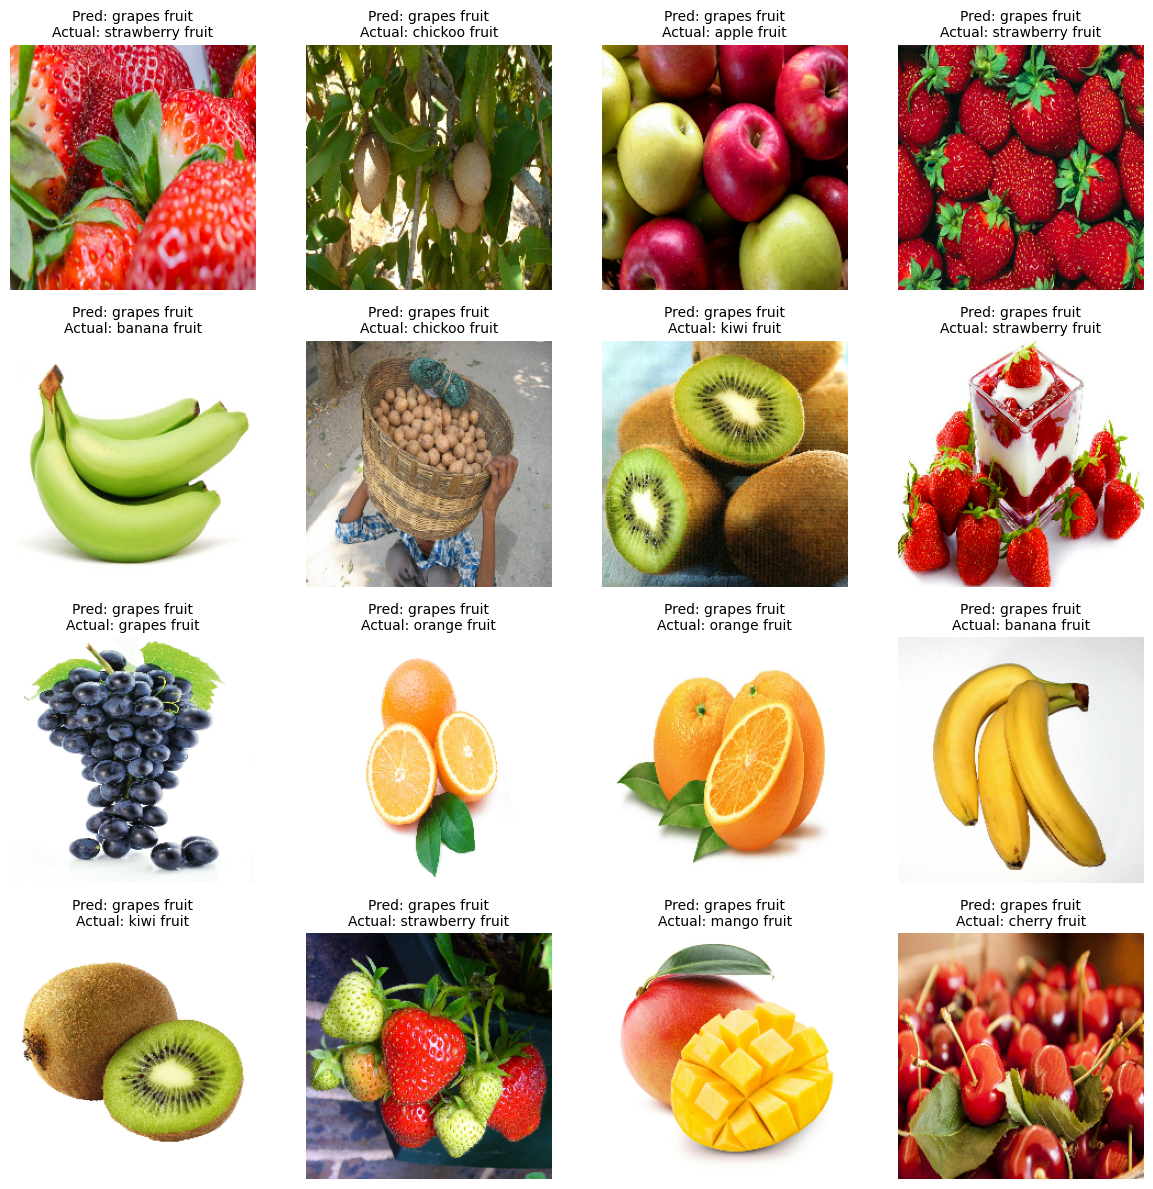

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import math

for images, labels in eval_dataset.take(1):

    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    num_images = images.shape[0]

    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)


        plt.imshow(images[i].numpy())
        plt.axis('off')

        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    plt.tight_layout()
    plt.show()